In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("results/figures",exist_ok=True)
df = pd.read_csv("XLRE.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print("XLRE data loaded successfully.")
print("shape:", df.shape)
df.head()

XLRE data loaded successfully.
shape: (2323, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-10-08,30.010000,30.209999,30.010000,30.209999,20.861324,2000
1,2015-10-09,30.200001,30.200001,30.059999,30.160000,20.826797,4300
2,2015-10-12,30.420000,30.420000,30.270000,30.350000,20.957996,2300
3,2015-10-13,30.160000,30.160000,30.160000,30.160000,20.826797,500
4,2015-10-14,30.160000,30.160000,30.160000,30.160000,20.826797,0


In [3]:
df.isnull().sum()
df.duplicated().sum()
df.info()
df.tail()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2323 entries, 0 to 2322
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2323 non-null   datetime64[ns]
 1   Open       2323 non-null   float64       
 2   High       2323 non-null   float64       
 3   Low        2323 non-null   float64       
 4   Close      2323 non-null   float64       
 5   Adj Close  2323 non-null   float64       
 6   Volume     2323 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 127.2 KB


,Date,Open,High,Low,Close,Adj Close,Volume
count,2323,2323.000000,2323.000000,2323.000000,2323.000000,2323.000000,2.323000e+03
mean,2020-05-19 18:32:41.945760,36.778231,37.028090,36.492051,36.771103,30.173065,4.438587e+06
min,2015-10-08 00:00:00,26.629999,26.920000,24.879999,25.459999,19.004429,0.000000e+00
25%,2018-01-29 12:00:00,32.410000,32.552500,32.181000,32.400002,24.098669,2.232150e+06
50%,2020-05-20 00:00:00,36.330002,36.570000,35.959999,36.250000,30.046232,3.943200e+06
75%,2022-09-08 12:00:00,39.410000,39.684999,39.157501,39.470001,35.222940,5.787950e+06
max,2024-12-31 00:00:00,51.980000,52.169998,51.660000,51.810001,44.454338,4.989980e+07
std,NaN,5.134833,5.174311,5.086617,5.134105,6.303078,3.584859e+06


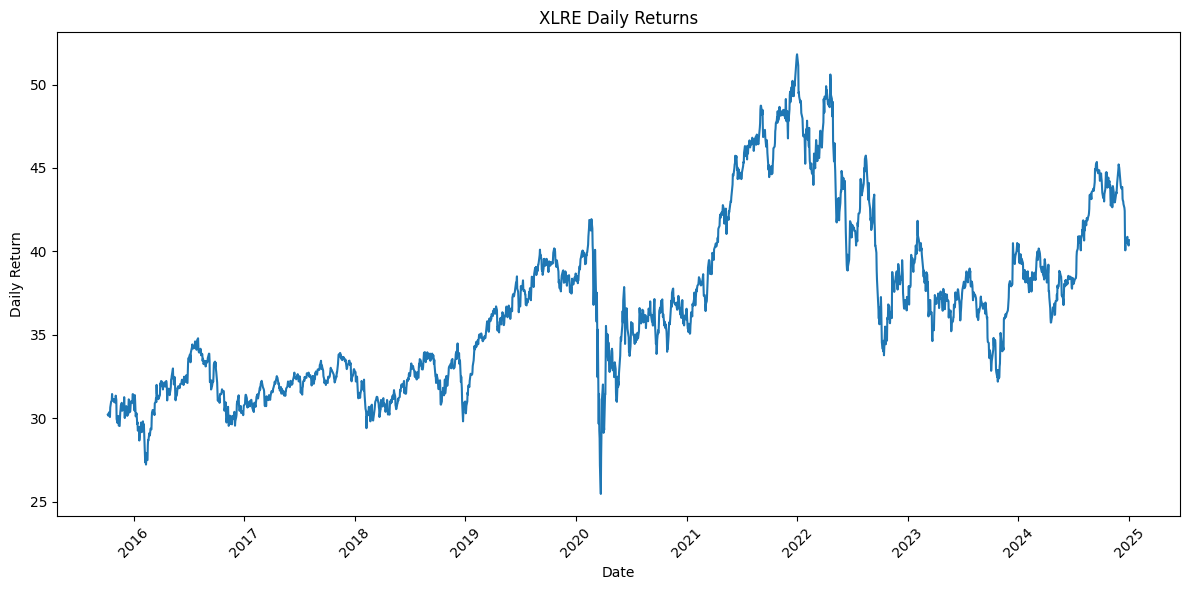

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import matplotlib.pyplot as plt
from google.colab import files
import os
os.makedirs("results/figures", exist_ok=True)

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"])
plt.title("XLRE Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()
file_path = "results/figures/XLRE_Daily_Returns.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)

In [9]:
df["Daily_Return"] = df["Close"].pct_change()
df[["Date","Close","Daily_Return"]].head(10)
print("Daily Return Statistics:")
print(df["Daily_Return"].describe())

Daily Return Statistics:
count    2322.000000
mean        0.000216
std         0.013227
min        -0.160011
25%        -0.005966
50%         0.000798
75%         0.006778
max         0.087800
Name: Daily_Return, dtype: float64


In [12]:
print("missing values before cleaning:")
print(df["Daily_Return"].isnull().sum())

missing values before cleaning:
1


In [13]:
df = df.dropna(subset=["Daily_Return"]).reset_index(drop=True)
print("\nMissing values after cleaning:")
print(df["Daily_Return"].isnull().sum())



Missing values after cleaning:
0


In [14]:
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()
df[["Date","Close","MA_10","MA_20","MA_50"]].tail()

,Date,Close,MA_10,MA_20,MA_50
2317,2024-12-24,40.810001,41.687,42.9455,43.4184
2318,2024-12-26,40.869999,41.470,42.7440,43.3502
2319,2024-12-27,40.540001,41.223,42.5105,43.2666
2320,2024-12-30,40.349998,40.975,42.2780,43.1850
2321,2024-12-31,40.669998,40.781,42.0955,43.1036


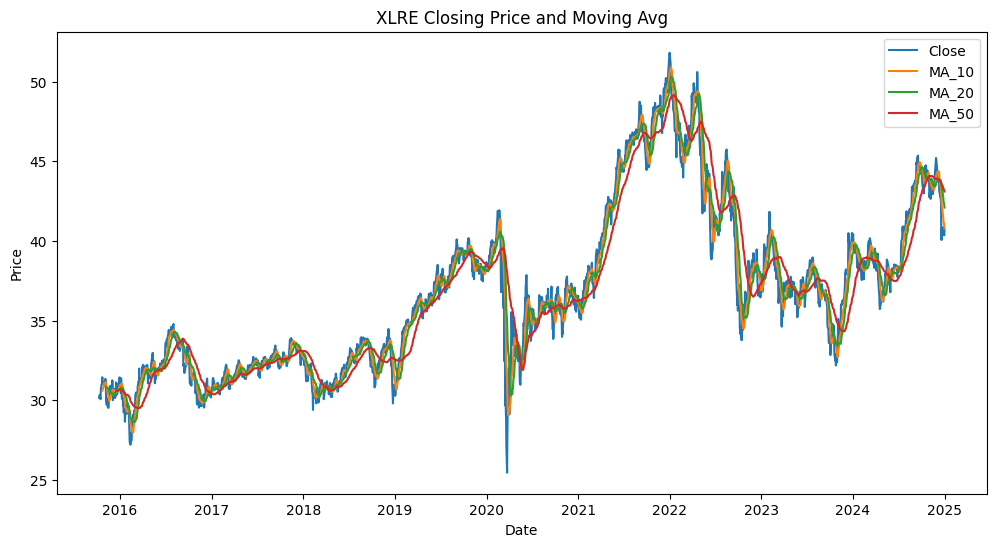

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import matplotlib.pyplot as plt
from google.colab import files
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_10"], label="MA_10")
plt.plot(df["Date"], df["MA_20"], label="MA_20")
plt.plot(df["Date"], df["MA_50"], label="MA_50")
plt.title("XLRE Closing Price and Moving Avg")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
file_path = "XLRE_Moving_Avg.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()
files.download(file_path)


In [18]:
print("XLRE Moving Avg Features:")
display(df[["Date","Close","MA_10","MA_20","MA_50"]].tail())

XLRE Moving Avg Features:


,Date,Close,MA_10,MA_20,MA_50
2317,2024-12-24,40.810001,41.687,42.9455,43.4184
2318,2024-12-26,40.869999,41.470,42.7440,43.3502
2319,2024-12-27,40.540001,41.223,42.5105,43.2666
2320,2024-12-30,40.349998,40.975,42.2780,43.1850
2321,2024-12-31,40.669998,40.781,42.0955,43.1036


In [19]:
df["Volatility_20"] = df["Daily_Return"].rolling(window=20).std()

display(df[["Date", "Daily_Return", "Volatility_20"]].tail(10))

,Date,Daily_Return,Volatility_20
2312,2024-12-17,-0.004459,0.007204
2313,2024-12-18,-0.039132,0.011036
2314,2024-12-19,-0.017174,0.011456
2315,2024-12-20,0.018223,0.012284
2316,2024-12-23,-0.006129,0.012019
2317,2024-12-24,0.006660,0.011590
2318,2024-12-26,0.001470,0.011468
2319,2024-12-27,-0.008074,0.011160
2320,2024-12-30,-0.004687,0.011160
2321,2024-12-31,0.007931,0.011291


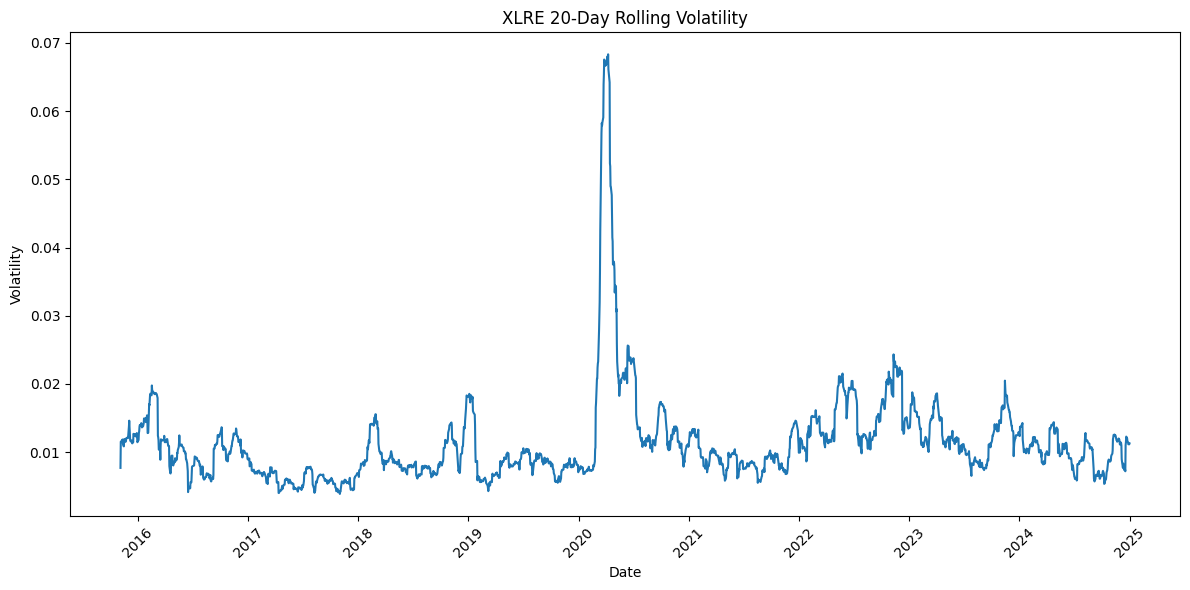

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Volatility_20"])

plt.title("XLRE 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "XLRE_Volatility_20.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

files.download(file_path)

In [21]:
print("Volatility feature created successfully.")
print(df["Volatility_20"].describe())

Volatility feature created successfully.
count    2303.000000
mean        0.011321
std         0.006976
min         0.003883
25%         0.007753
50%         0.009862
75%         0.012641
max         0.068321
Name: Volatility_20, dtype: float64


In [22]:
# Calculate RSI (14-period)
delta = df["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI_14"] = 100 - (100 / (1 + rs))

display(df[["Date", "Close", "RSI_14"]].tail(10))

,Date,Close,RSI_14
2312,2024-12-17,42.419998,12.195057
2313,2024-12-18,40.759998,1.943847
2314,2024-12-19,40.060001,1.757816
2315,2024-12-20,40.790001,15.860735
2316,2024-12-23,40.540001,15.891467
2317,2024-12-24,40.810001,20.527319
2318,2024-12-26,40.869999,21.863081
2319,2024-12-27,40.540001,20.795638
2320,2024-12-30,40.349998,18.827675
2321,2024-12-31,40.669998,26.335836


In [23]:
# Calculate MACD
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26

# MACD Signal
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

display(df[["Date", "Close", "MACD", "MACD_Signal"]].tail(10))

,Date,Close,MACD,MACD_Signal
2312,2024-12-17,42.419998,-0.287148,-0.094250
2313,2024-12-18,40.759998,-0.463337,-0.168068
2314,2024-12-19,40.060001,-0.651936,-0.264841
2315,2024-12-20,40.790001,-0.734036,-0.358680
2316,2024-12-23,40.540001,-0.809937,-0.448932
2317,2024-12-24,40.810001,-0.838636,-0.526872
2318,2024-12-26,40.869999,-0.846777,-0.590853
2319,2024-12-27,40.540001,-0.869830,-0.646649
2320,2024-12-30,40.349998,-0.893136,-0.695946
2321,2024-12-31,40.669998,-0.875690,-0.731895


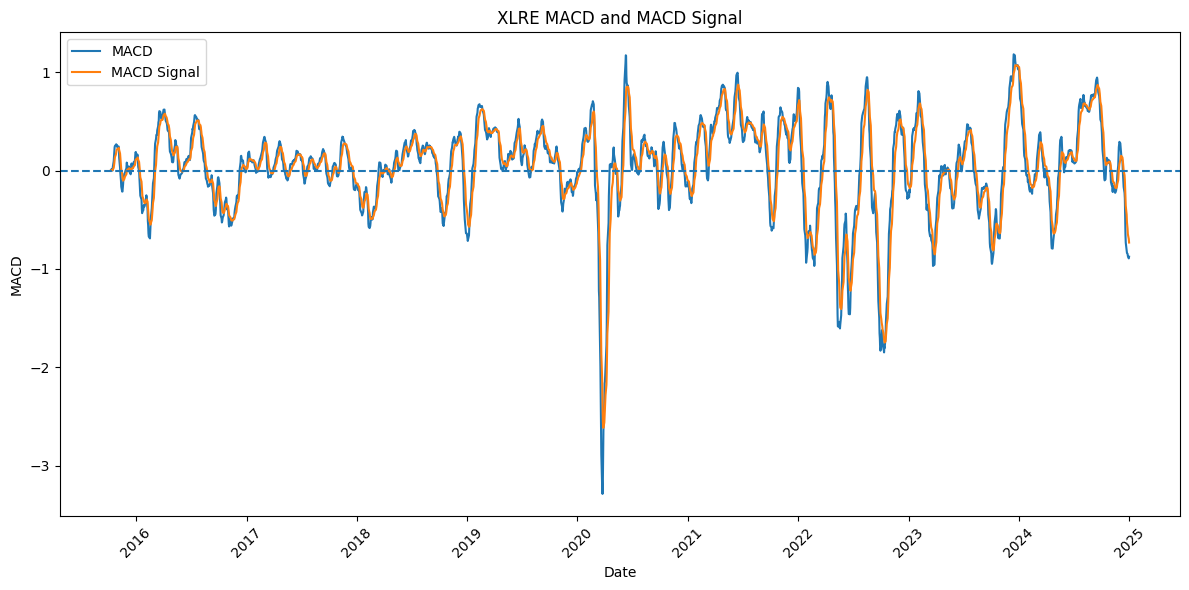

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_Signal"], label="MACD Signal")

plt.axhline(0, linestyle="--")

plt.title("XLRE MACD and MACD Signal")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "XLRE_MACD.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

files.download(file_path)

In [25]:
features = [
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

print("XLRE Feature Engineering Summary:")
display(df[["Date", "Close"] + features].tail(10))

XLRE Feature Engineering Summary:


,Date,Close,Daily_Return,MA_10,MA_20,MA_50,Volatility_20,RSI_14,MACD,MACD_Signal
2312,2024-12-17,42.419998,-0.004459,43.246,43.7745,43.6958,0.007204,12.195057,-0.287148,-0.094250
2313,2024-12-18,40.759998,-0.039132,42.928,43.6355,43.6444,0.011036,1.943847,-0.463337,-0.168068
2314,2024-12-19,40.060001,-0.017174,42.551,43.4650,43.5786,0.011456,1.757816,-0.651936,-0.264841
2315,2024-12-20,40.790001,0.018223,42.253,43.3165,43.5346,0.012284,15.860735,-0.734036,-0.358680
2316,2024-12-23,40.540001,-0.006129,41.921,43.1390,43.4768,0.012019,15.891467,-0.809937,-0.448932
2317,2024-12-24,40.810001,0.006660,41.687,42.9455,43.4184,0.011590,20.527319,-0.838636,-0.526872
2318,2024-12-26,40.869999,0.001470,41.470,42.7440,43.3502,0.011468,21.863081,-0.846777,-0.590853
2319,2024-12-27,40.540001,-0.008074,41.223,42.5105,43.2666,0.011160,20.795638,-0.869830,-0.646649
2320,2024-12-30,40.349998,-0.004687,40.975,42.2780,43.1850,0.011160,18.827675,-0.893136,-0.695946
2321,2024-12-31,40.669998,0.007931,40.781,42.0955,43.1036,0.011291,26.335836,-0.875690,-0.731895


In [27]:
# Remove rows with missing values from feature engineering
df_features = df.dropna().copy()

# Reset index
df_features = df_features.reset_index(drop=True)

print("Original shape:", df.shape)
print("Final feature dataset shape:", df_features.shape)

print("\nMissing values:")
print(df_features.isnull().sum())

Original shape: (2322, 15)
Final feature dataset shape: (2273, 15)

Missing values:
Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Daily_Return     0
MA_10            0
MA_20            0
MA_50            0
Volatility_20    0
RSI_14           0
MACD             0
MACD_Signal      0
dtype: int64


In [28]:
final_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

df_features = df_features[final_columns]

display(df_features.head())

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA_10,MA_20,MA_50,Volatility_20,RSI_14,MACD,MACD_Signal
0,2015-12-18,30.563000,30.590000,30.350000,30.35,21.189724,1400,-0.023802,30.5709,30.6114,30.58062,0.012691,45.852345,0.043411,0.023240
1,2015-12-21,30.455999,30.455999,30.400000,30.40,21.224636,500,0.001647,30.5489,30.5934,30.58542,0.012547,40.155832,0.024487,0.023490
2,2015-12-22,30.680000,30.680000,30.680000,30.68,21.420128,200,0.009211,30.5449,30.5814,30.59202,0.012674,50.749245,0.031718,0.025135
3,2015-12-23,30.750000,30.980000,30.750000,30.98,21.629578,4500,0.009778,30.5879,30.6079,30.60842,0.012357,63.129409,0.060953,0.032299
4,2015-12-24,30.856001,31.010000,30.856001,31.01,21.650526,300,0.000968,30.6589,30.6359,30.62542,0.012355,56.262043,0.085557,0.042950


In [29]:
from google.colab import files

file_path = "XLRE_features.csv"

df_features.to_csv(file_path, index=False)

print("XLRE feature dataset saved successfully.")
print("Rows:", len(df_features))
print("Columns:", len(df_features.columns))

files.download(file_path)

XLRE feature dataset saved successfully.
Rows: 2273
Columns: 15


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
print("FINAL XLRE DATASET CHECK")
print("=" * 40)

print("Shape:", df_features.shape)
print("\nColumns:")
print(df_features.columns.tolist())

print("\nMissing values:")
print(df_features.isnull().sum())

print("\nDuplicate rows:")
print(df_features.duplicated().sum())

print("\nDate range:")
print(df_features["Date"].min(), "to", df_features["Date"].max())

FINAL XLRE DATASET CHECK
Shape: (2273, 15)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'MA_10', 'MA_20', 'MA_50', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal']

Missing values:
Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Daily_Return     0
MA_10            0
MA_20            0
MA_50            0
Volatility_20    0
RSI_14           0
MACD             0
MACD_Signal      0
dtype: int64

Duplicate rows:
0

Date range:
2015-12-18 00:00:00 to 2024-12-31 00:00:00


In [31]:
# Create next-day target
df_ml = df_features.copy()

df_ml["Target"] = df_ml["Close"].shift(-1)

# Remove final row with missing target
df_ml = df_ml.dropna().reset_index(drop=True)

print("Target created successfully.")
display(df_ml[["Date", "Close", "Target"]].head(10))

Target created successfully.


,Date,Close,Target
0,2015-12-18,30.350000,30.400000
1,2015-12-21,30.400000,30.680000
2,2015-12-22,30.680000,30.980000
3,2015-12-23,30.980000,31.010000
4,2015-12-24,31.010000,30.927000
5,2015-12-28,30.927000,31.440001
6,2015-12-29,31.440001,31.440001
7,2015-12-30,31.440001,31.184000
8,2015-12-31,31.184000,30.459999
9,2016-01-04,30.459999,31.382999


In [32]:
feature_columns = [
    "Close",
    "Daily_Return",
    "MA_10",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

X = df_ml[feature_columns]
y = df_ml["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2272, 9)
y shape: (2272,)


In [33]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(df_ml["Date"].iloc[:split_index].min(), "to",
      df_ml["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(df_ml["Date"].iloc[split_index], "to",
      df_ml["Date"].iloc[-1])

Training samples: 1817
Testing samples: 455

Training period:
2015-12-18 00:00:00 to 2023-03-09 00:00:00

Testing period:
2023-03-10 00:00:00 to 2024-12-30 00:00:00


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [37]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_test shape: (455, 9)
y_test shape: (455,)
X_test_scaled shape: (455, 9)


In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model training completed successfully.")

# Prediction
y_pred = model.predict(X_test_scaled)

print("Prediction completed successfully.")
print("Number of predictions:", len(y_pred))
print(y_pred[:10])

Model training completed successfully.
Prediction completed successfully.
Number of predictions: 455
[36.16619217 36.59750636 37.06309274 37.14874118 37.15031577 36.35123667
 36.37373261 36.20519828 34.95327192 34.63051663]


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

actual = np.array(y_test)
predicted = np.array(y_pred)

mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(actual, predicted)

print("XLRE MODEL EVALUATION")
print("=" * 40)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

XLRE MODEL EVALUATION
MAE  : 0.3288
MSE  : 0.1855
RMSE : 0.4307
R²   : 0.9796


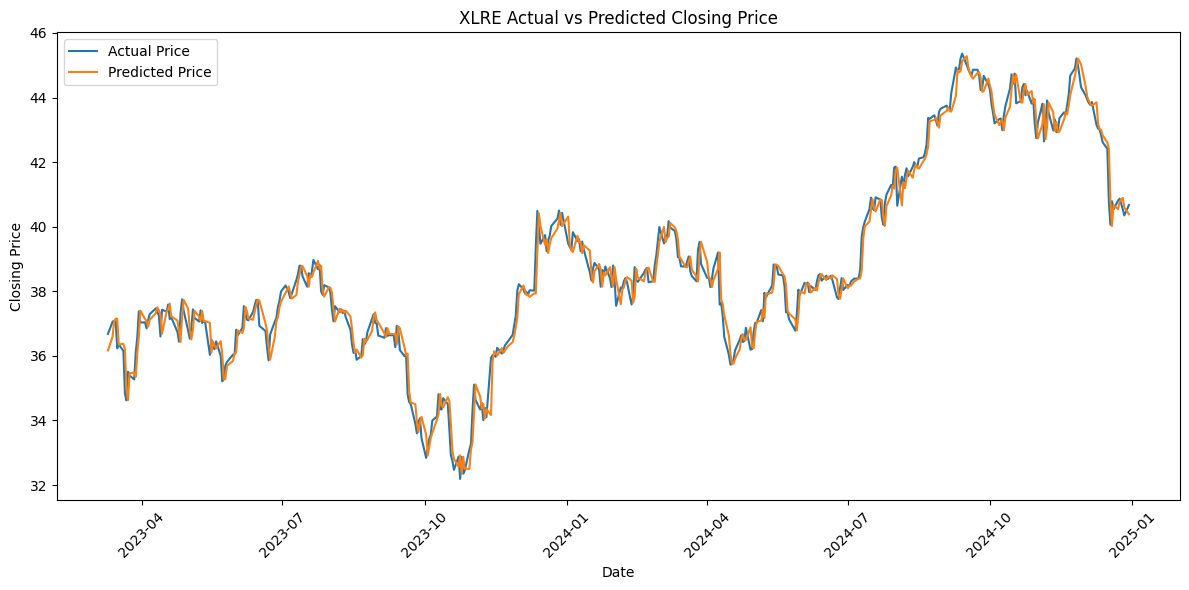

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
import matplotlib.pyplot as plt
from google.colab import files

test_dates = df_ml["Date"].iloc[split_index:].reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.plot(test_dates, actual, label="Actual Price")
plt.plot(test_dates, predicted, label="Predicted Price")

plt.title("XLRE Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

file_path = "XLRE_Actual_vs_Predicted.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

files.download(file_path)

In [42]:
evaluation_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})

display(evaluation_results)

evaluation_results.to_csv("XLRE_Evaluation_Metrics.csv", index=False)

files.download("XLRE_Evaluation_Metrics.csv")

,Metric,Value
0,MAE,0.328765
1,MSE,0.185483
2,RMSE,0.430678
3,R2,0.979572


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
prediction_results = pd.DataFrame({
    "Date": test_dates,
    "Actual": actual,
    "Predicted": predicted
})

prediction_results["Error"] = (
    prediction_results["Actual"] - prediction_results["Predicted"]
)

prediction_results.to_csv("XLRE_Prediction_Results.csv", index=False)

files.download("XLRE_Prediction_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

XLRE MODEL EVALUATION RESULTS
MAE  : 0.3288
MSE  : 0.1855
RMSE : 0.4307
R²   : 0.9796

FIRST 10 PREDICTIONS:


,Date,Actual,Predicted,Error
0,2023-03-10,36.680000,36.166192,0.513808
1,2023-03-13,37.060001,36.597506,0.462495
2,2023-03-14,37.080002,37.063093,0.016909
3,2023-03-15,37.080002,37.148741,-0.068739
4,2023-03-16,36.230000,37.150316,-0.920316
5,2023-03-17,36.360001,36.351237,0.008764
6,2023-03-20,36.150002,36.373733,-0.223731
7,2023-03-21,34.830002,36.205198,-1.375196
8,2023-03-22,34.619999,34.953272,-0.333273
9,2023-03-23,35.509998,34.630517,0.879482


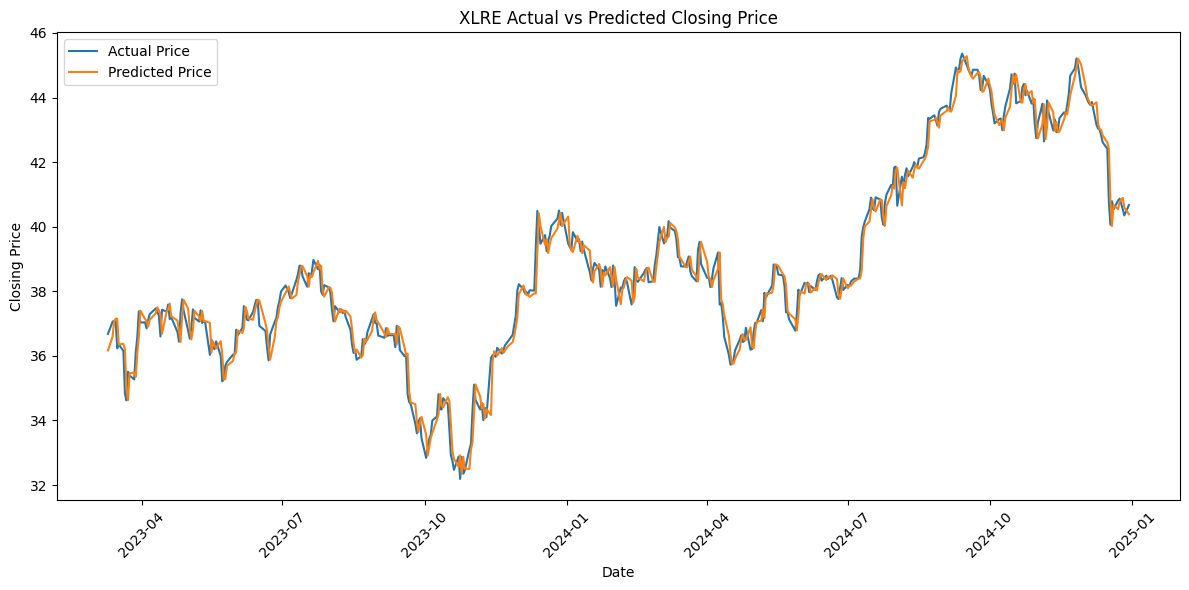

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All XLRE evaluation files saved and downloaded successfully.


In [44]:
# ==========================================
# XLRE COMPLETE MODEL EVALUATION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

# 1. Prepare actual and predicted values
actual = np.array(y_test)
predicted = np.array(y_pred)

# 2. Calculate evaluation metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(actual, predicted)

# 3. Display metrics
print("=" * 50)
print("XLRE MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print("=" * 50)

# 4. Prepare test dates
test_dates = df_ml["Date"].iloc[split_index:].reset_index(drop=True)

# 5. Create prediction results table
prediction_results = pd.DataFrame({
    "Date": test_dates,
    "Actual": actual,
    "Predicted": predicted
})

prediction_results["Error"] = (
    prediction_results["Actual"] -
    prediction_results["Predicted"]
)

# 6. Save prediction results
prediction_results.to_csv(
    "XLRE_Prediction_Results.csv",
    index=False
)

# 7. Create evaluation metrics table
evaluation_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})

# 8. Save evaluation metrics
evaluation_results.to_csv(
    "XLRE_Evaluation_Metrics.csv",
    index=False
)

# 9. Display prediction results
print("\nFIRST 10 PREDICTIONS:")
display(prediction_results.head(10))

# 10. Actual vs Predicted plot
plt.figure(figsize=(12, 6))

plt.plot(
    test_dates,
    actual,
    label="Actual Price"
)

plt.plot(
    test_dates,
    predicted,
    label="Predicted Price"
)

plt.title("XLRE Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "XLRE_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 11. Download all results
files.download("XLRE_Actual_vs_Predicted.png")
files.download("XLRE_Evaluation_Metrics.csv")
files.download("XLRE_Prediction_Results.csv")

print("\nAll XLRE evaluation files saved and downloaded successfully.")